In [1]:
from datetime import datetime
from uuid import uuid4

import numpy as np
from dateutil import tz

from pynwb import NWBHDF5IO, NWBFile, TimeSeries
from pynwb.behavior import Position, SpatialSeries
from pynwb.epoch import TimeIntervals
from pynwb.file import Subject


First we create demo NWB file, write it, and read it

In [2]:
session_start_time = datetime(2018, 4, 25, 2, 30, 3, tzinfo=tz.gettz("US/Pacific"))

nwbfile = NWBFile(
    session_description="Mouse exploring an open field",  # required
    identifier=str(uuid4()),  # required
    session_start_time=session_start_time,  # required
    session_id="session_1234",  # optional
    experimenter=[
        "Brin, David",
    ],  # optional
    lab="Bag End Laboratory",  # optional
    institution="University of My Institution",  # optional
    experiment_description="I went on an adventure to reclaim vast treasures.",  # optional
    related_publications="DOI:10.1016/j.neuron.2016.12.011",  # optional
)
nwbfile


root pynwb.file.NWBFile at 0x1926970360656
Fields:
  experiment_description: I went on an adventure to reclaim vast treasures.
  experimenter: ['Brin, David']
  file_create_date: [datetime.datetime(2024, 2, 14, 10, 50, 22, 328259, tzinfo=tzlocal())]
  identifier: 1ce087e6-7297-4fbb-a0b1-dcbe435379ba
  institution: University of My Institution
  lab: Bag End Laboratory
  related_publications: ['DOI:10.1016/j.neuron.2016.12.011']
  session_description: Mouse exploring an open field
  session_id: session_1234
  session_start_time: 2018-04-25 02:30:03-07:00
  timestamps_reference_time: 2018-04-25 02:30:03-07:00

In [3]:
subject = Subject(
    subject_id="001",
    age="P90D",
    description="mouse 5",
    species="Mus musculus",
    sex="M",
)

nwbfile.subject = subject
subject

subject pynwb.file.Subject at 0x1926970360464
Fields:
  age: P90D
  age__reference: birth
  description: mouse 5
  sex: M
  species: Mus musculus
  subject_id: 001

In [4]:
data = list(range(100, 200, 10))
time_series_with_rate = TimeSeries(
    name="test_timeseries",
    data=data,
    unit="m",
    starting_time=0.0,
    rate=1.0,
)
time_series_with_rate

test_timeseries pynwb.base.TimeSeries at 0x1928058978912
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  offset: 0.0
  rate: 1.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: m

In [5]:
timestamps = list(range(10))
time_series_with_timestamps = TimeSeries(
    name="test_timeseries",
    data=data,
    unit="m",
    timestamps=timestamps,
)
time_series_with_timestamps

test_timeseries pynwb.base.TimeSeries at 0x1926970365504
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: [0 1 2 3 4 5 6 7 8 9]
  timestamps_unit: seconds
  unit: m

In [6]:
nwbfile.add_acquisition(time_series_with_timestamps)

In [7]:
nwbfile.acquisition["test_timeseries"]

test_timeseries pynwb.base.TimeSeries at 0x1926970365504
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: [0 1 2 3 4 5 6 7 8 9]
  timestamps_unit: seconds
  unit: m

In [8]:
nwbfile.get_acquisition("test_timeseries")

test_timeseries pynwb.base.TimeSeries at 0x1926970365504
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: [0 1 2 3 4 5 6 7 8 9]
  timestamps_unit: seconds
  unit: m

In [9]:
# create fake data with shape (50, 2)
# the first dimension should always represent time
position_data = np.array([np.linspace(0, 10, 50), np.linspace(0, 8, 50)]).T
position_timestamps = np.linspace(0, 50).astype(float) / 200

spatial_series_obj = SpatialSeries(
    name="SpatialSeries",
    description="(x,y) position in open field",
    data=position_data,
    timestamps=position_timestamps,
    reference_frame="(0,0) is bottom left corner",
)
spatial_series_obj

SpatialSeries pynwb.behavior.SpatialSeries at 0x1926968502672
Fields:
  comments: no comments
  conversion: 1.0
  data: [[ 0.          0.        ]
 [ 0.20408163  0.16326531]
 [ 0.40816327  0.32653061]
 [ 0.6122449   0.48979592]
 [ 0.81632653  0.65306122]
 [ 1.02040816  0.81632653]
 [ 1.2244898   0.97959184]
 [ 1.42857143  1.14285714]
 [ 1.63265306  1.30612245]
 [ 1.83673469  1.46938776]
 [ 2.04081633  1.63265306]
 [ 2.24489796  1.79591837]
 [ 2.44897959  1.95918367]
 [ 2.65306122  2.12244898]
 [ 2.85714286  2.28571429]
 [ 3.06122449  2.44897959]
 [ 3.26530612  2.6122449 ]
 [ 3.46938776  2.7755102 ]
 [ 3.67346939  2.93877551]
 [ 3.87755102  3.10204082]
 [ 4.08163265  3.26530612]
 [ 4.28571429  3.42857143]
 [ 4.48979592  3.59183673]
 [ 4.69387755  3.75510204]
 [ 4.89795918  3.91836735]
 [ 5.10204082  4.08163265]
 [ 5.30612245  4.24489796]
 [ 5.51020408  4.40816327]
 [ 5.71428571  4.57142857]
 [ 5.91836735  4.73469388]
 [ 6.12244898  4.89795918]
 [ 6.32653061  5.06122449]
 [ 6.53061224  5.2244898 ]
 [ 6.73469388  5.3877551 ]
 [ 6.93877551  5.55102041]
 [ 7.14285714  5.71428571]
 [ 7.34693878  5.87755102]
 [ 7.55102041  6.04081633]
 [ 7.75510204  6.20408163]
 [ 7.95918367  6.36734694]
 [ 8.16326531  6.53061224]
 [ 8.36734694  6.69387755]
 [ 8.57142857  6.85714286]
 [ 8.7755102   7.02040816]
 [ 8.97959184  7.18367347]
 [ 9.18367347  7.34693878]
 [ 9.3877551   7.51020408]
 [ 9.59183673  7.67346939]
 [ 9.79591837  7.83673469]
 [10.          8.        ]]
  description: (x,y) position in open field
  interval: 1
  offset: 0.0
  reference_frame: (0,0) is bottom left corner
  resolution: -1.0
  timestamps: [0.         0.00510204 0.01020408 0.01530612 0.02040816 0.0255102
 0.03061224 0.03571429 0.04081633 0.04591837 0.05102041 0.05612245
 0.06122449 0.06632653 0.07142857 0.07653061 0.08163265 0.08673469
 0.09183673 0.09693878 0.10204082 0.10714286 0.1122449  0.11734694
 0.12244898 0.12755102 0.13265306 0.1377551  0.14285714 0.14795918
 0.15306122 0.15816327 0.16326531 0.16836735 0.17346939 0.17857143
 0.18367347 0.18877551 0.19387755 0.19897959 0.20408163 0.20918367
 0.21428571 0.21938776 0.2244898  0.22959184 0.23469388 0.23979592
 0.24489796 0.25      ]
  timestamps_unit: seconds
  unit: meters

In [10]:
# name is set to "Position" by default
position_obj = Position(spatial_series=spatial_series_obj)
position_obj

Position pynwb.behavior.Position at 0x1926970374528
Fields:
  spatial_series: {
    SpatialSeries <class 'pynwb.behavior.SpatialSeries'>
  }

In [11]:
behavior_module = nwbfile.create_processing_module(
    name="behavior", description="processed behavioral data"
)
behavior_module.add(position_obj)
behavior_module

behavior pynwb.base.ProcessingModule at 0x1926970372608
Fields:
  data_interfaces: {
    Position <class 'pynwb.behavior.Position'>
  }
  description: processed behavioral data

In [12]:
nwbfile.processing["behavior"]

behavior pynwb.base.ProcessingModule at 0x1926970372608
Fields:
  data_interfaces: {
    Position <class 'pynwb.behavior.Position'>
  }
  description: processed behavioral data

In [13]:
io = NWBHDF5IO("basics_tutorial.nwb", mode="w")
io.write(nwbfile)
io.close()

C:\Python312\Lib\site-packages\hdmf\build\objectmapper.py:260: DtypeConversionWarning: Spec 'TimeSeries/timestamps': Value with data type int32 is being converted to data type float64 as specified.
  warnings.warn(full_warning_msg, DtypeConversionWarning)


In [14]:
with NWBHDF5IO("basics_tutorial.nwb", "w") as io:
    io.write(nwbfile)

In [15]:
with NWBHDF5IO("basics_tutorial.nwb", "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile.acquisition["test_timeseries"])
    print(read_nwbfile.acquisition["test_timeseries"].data[:])

test_timeseries pynwb.base.TimeSeries at 0x1926970366176
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (10,), type "<i4">
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: <HDF5 dataset "timestamps": shape (10,), type "<f8">
  timestamps_unit: seconds
  unit: m

[100 110 120 130 140 150 160 170 180 190]


In [16]:
with NWBHDF5IO("basics_tutorial.nwb", "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile.acquisition["test_timeseries"].data[:2])

[100 110]


tutorial NWD successfully read

moving on to first file from Primate Cell Type database

In [3]:
%pip install matplotlib

import matplotlib as plt

Note: you may need to restart the kernel to use updated packages.


In [59]:

import h5py


# Specify the file path
file_path = r"C:\Users\david\Downloads\M03_SM_A1_C09.nwb"

# Read the NWB file
with h5py.File(file_path, "r") as f:
    print("Keys: %s" % f.keys())
    for group in f.keys():
        print(group)

    keys = list(f.keys())

    for key in keys:
        # Check if the key corresponds to a group or dataset
        if isinstance(f[key], h5py.Group):
            # If it's a group, print the group name
            print("Group:", key)
            # Iterate over the keys (subgroup and dataset names) in the group
            for subkey in f[key].keys():
                # Check if the subkey corresponds to a dataset
                if isinstance(f[key][subkey], h5py.Dataset):
                    # If it's a dataset, print the dataset name and display its data
                    print("  Dataset:", subkey)
                    # Access and display the data in the dataset
                    data = f[key][subkey][...]
                    print("    Data:", data)
        elif isinstance(f[key], h5py.Dataset):
            # If it's a dataset at the root level, print the dataset name and display its data
            print("Dataset:", key)
            # Access and display the data in the dataset
            data = f[key][...]
            print("  Data:", data)
# Now you can access data stored in the NWB file
# For example, you can print the metadata



Keys: <KeysViewHDF5 ['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'scratch', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time']>
acquisition
analysis
file_create_date
general
identifier
intervals
processing
scratch
session_description
session_start_time
specifications
stimulus
timestamps_reference_time
Group: acquisition
Group: analysis
Dataset: file_create_date
  Data: [b'2023-03-28T00:47:47.307372-04:00']
Group: general
  Dataset: experiment_description
    Data: b'Characterizing intrinsic biophysical properties of cortical NHP neurons.'
  Dataset: institution
    Data: b'University of Western Ontario'
  Dataset: lab
    Data: b'Martinez-Trujillo/Inoue'
  Dataset: slices
    Data: b'ACSF slightly different to NeuroNex better description follows'
  Dataset: source_script
    Data: b'custom matlab script using MATNWB'
  Dataset: surgery
    Data: b'Bioopsies; Anaesthesia; choline-

In [45]:
with h5py.File(file_path, "r") as f:
    print("Keys: %s" % f.keys())
    for key in f.keys():
        if isinstance(f[key], h5py.Group):
            print(key)
            print(f[key].keys())
            for sweep in f[key].keys():
                if isinstance(f[key][sweep], h5py.Group):
                    print(key + ", " + sweep)
                    print(f[key][sweep].keys())
    

Keys: <KeysViewHDF5 ['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'scratch', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time']>
acquisition
<KeysViewHDF5 ['Sweep_0', 'Sweep_1', 'Sweep_10', 'Sweep_11', 'Sweep_12', 'Sweep_13', 'Sweep_14', 'Sweep_2', 'Sweep_3', 'Sweep_4', 'Sweep_5', 'Sweep_6', 'Sweep_7', 'Sweep_8', 'Sweep_9']>
acquisition, Sweep_0
<KeysViewHDF5 ['bias_current', 'bridge_balance', 'capacitance_compensation', 'data', 'electrode', 'starting_time']>
acquisition, Sweep_1
<KeysViewHDF5 ['bias_current', 'bridge_balance', 'capacitance_compensation', 'data', 'electrode', 'starting_time']>
acquisition, Sweep_10
<KeysViewHDF5 ['bias_current', 'bridge_balance', 'capacitance_compensation', 'data', 'electrode', 'starting_time']>
acquisition, Sweep_11
<KeysViewHDF5 ['bias_current', 'bridge_balance', 'capacitance_compensation', 'data', 'electrode', 'starting_time']>
acquisition, Swe

In [19]:
import sys
print(sys.path)

['C:\\Users\\david\\Documents\\Voytek Research', 'C:\\Python312\\python312.zip', 'C:\\Python312\\DLLs', 'C:\\Python312\\Lib', 'C:\\Python312', '', 'C:\\Users\\david\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Python312\\Lib\\site-packages', 'C:\\Python312\\Lib\\site-packages\\win32', 'C:\\Python312\\Lib\\site-packages\\win32\\lib', 'C:\\Python312\\Lib\\site-packages\\Pythonwin']


In [20]:
f

<Closed HDF5 file>

C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


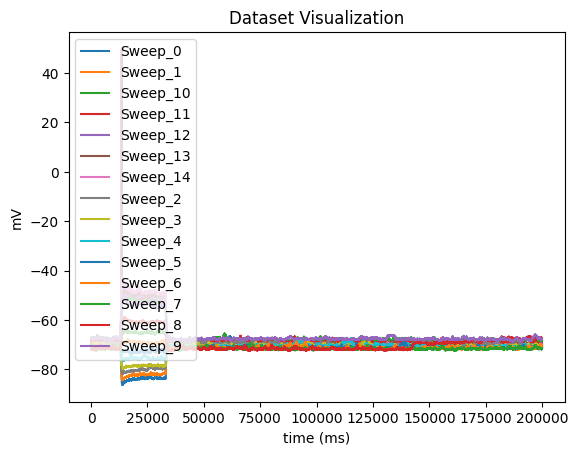

In [55]:
import h5py
import matplotlib.pyplot as plt

# Open the HDF5 file
with h5py.File(file_path, 'r') as f:
    # Get the names of all datasets in the 'acquisition' group
    sweep_keys = list(f['acquisition'].keys())
    
    # Plot each dataset
    for sweep in sweep_keys:
        # Get the dataset
        dataset = f['acquisition'][sweep]['data'][:]
        
        # Plot the dataset
        plt.plot(dataset, label=sweep)

    # Add labels and legend
    plt.xlabel('time (ms)')
    plt.ylabel('mV')
    plt.title('Dataset Visualization')
    plt.legend()
    
    # Show the plot
    plt.show()


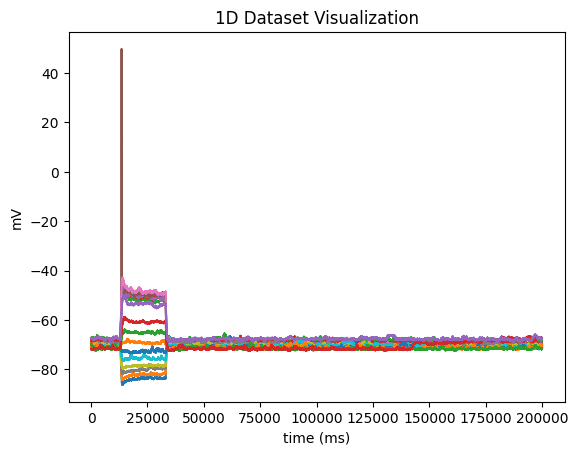

array([[-69.2168045 , -69.16797638, -69.2168045 , ..., -68.86890411,
        -68.80176544, -68.7834549 ],
       [-68.85059357, -68.83838654, -68.77735138, ..., -69.96753693,
        -70.02857208, -70.02857208],
       [-67.72754669, -67.84351349, -67.77637482, ..., -68.52710724,
        -68.48438263, -68.44776154],
       ...,
       [-70.20557404, -70.29102325, -70.26660919, ..., -71.6765213 ,
        -71.6765213 , -71.72534943],
       [-71.7131424 , -71.6765213 , -71.6765213 , ..., -67.28809357,
        -67.32471466, -67.3003006 ],
       [-67.27588654, -67.34912872, -67.31861115, ..., -67.81909943,
        -67.78858185, -67.71533966]])

In [63]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def visualize_hdf5_data(file_path):
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Convert the list of arrays into a NumPy array
        data = np.array(data)

        # Plot the data
        
        for i in range(len(data)):
            plt.plot(data[i])
        plt.xlabel('time (ms)')
        plt.ylabel('mV')
        plt.title('1D Dataset Visualization')
        plt.show()

        return data

# Example usage:
#file_path = 'your_file.h5'
data = visualize_hdf5_data(file_path)
data

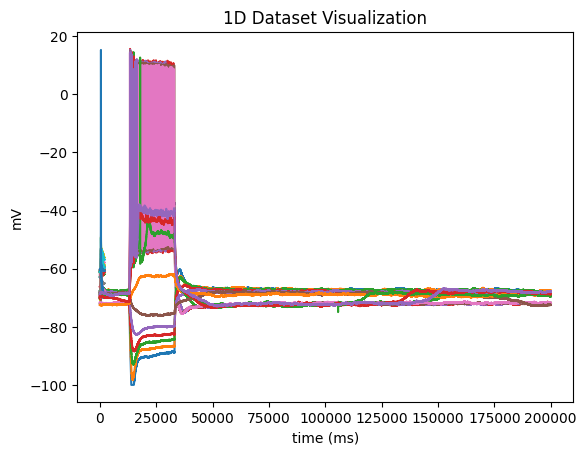

In [66]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def visualize_hdf5_data(file_path):
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Plot the data
        if all(d.ndim == 1 for d in data):
            for d in data:
                plt.plot(d)
            plt.xlabel('time (ms)')
            plt.ylabel('mV')
            plt.title('1D Dataset Visualization')
            plt.show()
        elif all(d.ndim == 2 for d in data):
            for d in data:
                plt.imshow(d, cmap='viridis')
                plt.colorbar()
                plt.xlabel('X-axis')
                plt.ylabel('Y-axis')
                plt.title('2D Dataset Visualization')
                plt.show()
        else:
            print("Cannot visualize data with more than 2 dimensions.")

        return data

# Example usage:
data = visualize_hdf5_data(file_path)


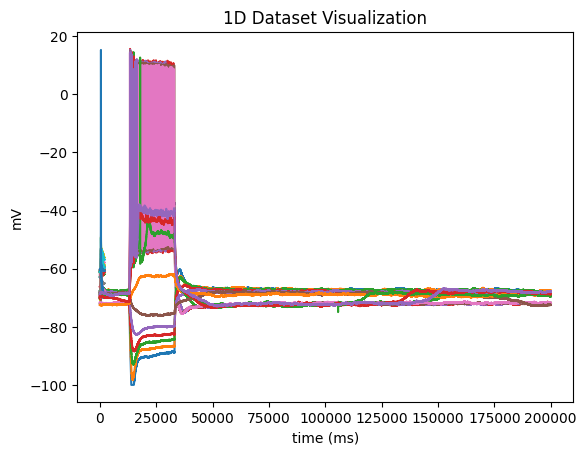

,data,location,species
0,"[-67.68493803631375, -67.71545561512087, -67.7...",b'University of Western OntarioMartinez-Trujil...,[b'Macaca fascicularis']
1,"[-68.05420073987992, -68.06335601352205, -68.0...",b'University of Western OntarioMartinez-Trujil...,[b'Macaca fascicularis']
2,"[-67.88025054067933, -67.86193999339505, -67.8...",b'University of Western OntarioMartinez-Trujil...,[b'Macaca fascicularis']
3,"[-68.17932281298911, -68.17321929722769, -68.1...",b'University of Western OntarioMartinez-Trujil...,[b'Macaca fascicularis']
4,"[-71.92382973262286, -71.96350258507212, -71.9...",b'University of Western OntarioMartinez-Trujil...,[b'Macaca fascicularis']


In [12]:
import h5py
import numpy as np
import pandas as pd

def visualize_hdf5_data_with_metadata(file_path):
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize lists to store data and metadata
        data = []
        metadata = {'location': [], 'species': [], 'sampling_rate': []}

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the data list
            data.append(np.array(dataset))
            
            # Extract metadata for the current dataset
            location = f['general']['institution'][()] + f['general']['lab'][()]
            species = f['general']['subject']['species'][()]
            sampling_rate = f['timestamps_reference_time'][()]
            
            # Append metadata to the metadata lists
            metadata['location'].append(location)
            metadata['species'].append(species)
            #metadata['timestamps_reference_time'].append(sampling_rate)

        # Create a DataFrame from the data and metadata
        df = pd.DataFrame({'data': data, 'location': metadata['location'], 
                           'species': metadata['species']})
        
        # Plot the data (assuming 1D data)
        for d in data:
            plt.plot(d)
        plt.xlabel('time (ms)')
        plt.ylabel('mV')
        plt.title('1D Dataset Visualization')
        plt.show()

        return df

# Example usage:
file_path =  r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C01.nwb"
df = visualize_hdf5_data_with_metadata(file_path)
df.head()


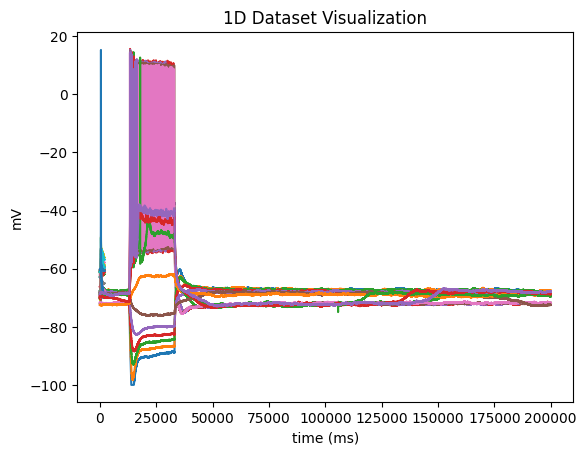

[array([-67.68493804, -67.71545562, -67.7093521 , ..., -68.02368316,
        -68.05420074, -68.03894195]),
 array([-68.05420074, -68.06335601, -68.04809722, ..., -67.55371245,
        -67.55676421, -67.57507475]),
 array([-67.88025054, -67.86193999, -67.83447417, ..., -68.17627106,
        -68.16406402, -68.15185699]),
 array([-68.17932281, -68.1732193 , -68.13354644, ..., -71.95129555,
        -71.92077797, -71.91467446]),
 array([-71.92382973, -71.96350259, -71.93603676, ..., -72.30224771,
        -72.23816079, -72.20764322]),
 array([-72.23205728, -72.23510904, -72.20459146, ..., -71.74072426,
        -71.7163102 , -71.75598305]),
 array([-71.70410317, -71.72851723, -71.72851723, ..., -71.79870766,
        -71.81091469, -71.76819008]),
 array([-69.77539218, -69.75708164, -69.70825351, ..., -69.59839023,
        -69.54345859, -69.59228671]),
 array([-70.03173985, -70.07446446, -70.09887852, ..., -69.91577305,
        -69.95849766, -69.90966953]),
 array([-69.72046054, -69.82422031, -

In [67]:


file_path = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C01.nwb"
data = visualize_hdf5_data(file_path)
data

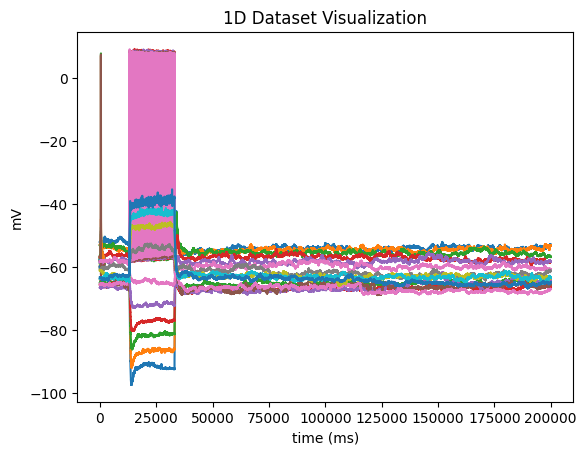

[array([-51.98974726, -51.97143671, -52.02026483, ..., -52.86255001,
        -52.89306759, -52.9357922 ]),
 array([-52.86255001, -52.8991711 , -52.94189571, ..., -53.06396603,
        -53.11279416, -53.051759  ]),
 array([-64.86816551, -64.85595848, -64.79492332, ..., -65.55786279,
        -65.52734521, -65.58227686]),
 array([-65.55786279, -65.59448389, -65.58838037, ..., -66.412355  ,
        -66.39404445, -66.33911281]),
 array([-66.40014797, -66.35131984, -66.39404445, ..., -63.79394674,
        -63.84277486, -63.78173971]),
 array([-63.74511861, -63.80005025, -63.76342916, ..., -65.42358545,
        -65.35644677, -65.43579248]),
 array([-65.34423974, -65.42358545, -65.32592919, ..., -66.94336087,
        -66.94336087, -66.8762222 ]),
 array([-57.24487433, -57.22046026, -57.17163214, ..., -56.95190557,
        -57.01294073, -56.98852666]),
 array([-60.04638806, -60.01587048, -59.97314587, ..., -60.3332533 ,
        -60.23559705, -60.24170057]),
 array([-60.27832166, -60.32104627, -

In [70]:
file_path = r'C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C03.nwb'
data = visualize_hdf5_data(file_path)
data

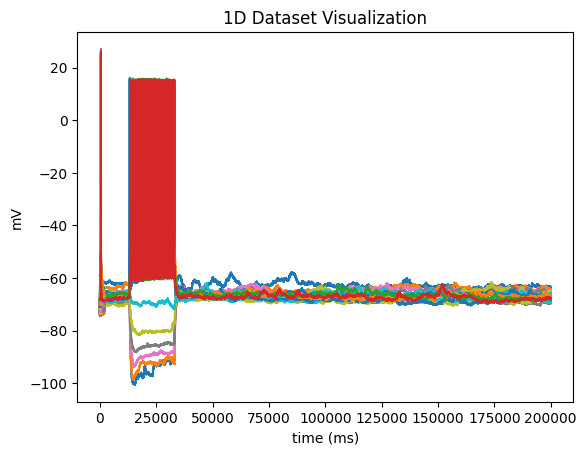

[array([-59.00879038, -58.97216929, -59.02099741, ..., -63.3911147 ,
        -63.43383931, -63.37280415]),
 array([-63.36059712, -63.45825337, -63.45214986, ..., -64.29443503,
        -64.2456069 , -64.22119284]),
 array([-67.71850737, -67.69409331, -67.65747222, ..., -68.15185699,
        -68.12133941, -68.09692535]),
 array([-70.81909338, -70.84350744, -70.80688635, ..., -65.63110498,
        -65.6372085 , -65.71045069]),
 array([-69.04907381, -69.00024568, -68.99414217, ..., -69.32983553,
        -69.29321444, -69.32373202]),
 array([-66.34521633, -66.31469875, -66.25976711, ..., -68.16406402,
        -68.21289215, -68.14575348]),
 array([-66.19873195, -66.1804214 , -66.24145656, ..., -67.83447417,
        -67.94433746, -67.91381988]),
 array([-68.15796051, -68.18237457, -68.09692535, ..., -69.56176913,
        -69.63501132, -69.61670077]),
 array([-69.57397616, -69.64721835, -69.68994296, ..., -68.64013825,
        -68.56689606, -68.59741364]),
 array([-68.6584488 , -68.57299958, -

In [71]:

file_path = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C04.nwb"
data = visualize_hdf5_data(file_path)
data

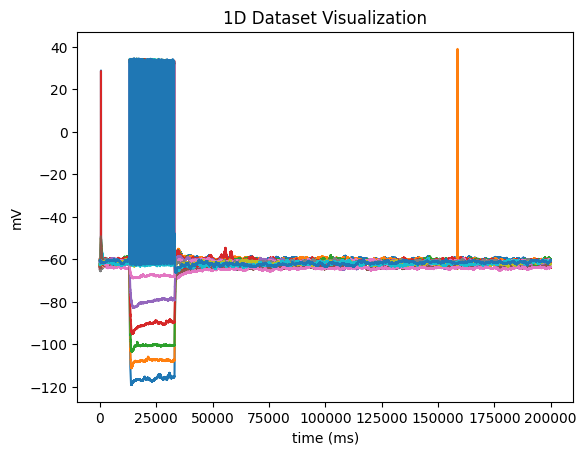

[array([-63.43994282, -63.41552876, -63.37280415, ..., -60.75439589,
        -60.74218886, -60.79101698]),
 array([-60.70556776, -60.77880995, -60.75439589, ..., -60.46142713,
        -60.40649549, -60.47973768]),
 array([-60.18066541, -60.24170057, -60.22339002, ..., -59.77783337,
        -59.83886853, -59.7900404 ]),
 array([-59.78393688, -59.83276501, -59.77172985, ..., -64.00146627,
        -63.90381002, -63.92212057]),
 array([-63.9343276 , -63.89770651, -63.9709487 , ..., -62.13989397,
        -62.07885881, -62.17651506]),
 array([-62.1154799 , -62.17041155, -62.16430803, ..., -63.67187642,
        -63.61694478, -63.63525533]),
 array([-63.6230483 , -63.58032369, -63.62915181, ..., -63.64135884,
        -63.63525533, -63.67797994]),
 array([-64.85595848, -64.87426903, -64.90478661, ..., -63.56201314,
        -63.57422017, -63.51318501]),
 array([-62.02392717, -62.06054826, -62.05444475, ..., -62.04834123,
        -62.04834123, -61.9995131 ]),
 array([-61.8042006 , -61.82861466, -

In [72]:

file_path = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C06.nwb"
data = visualize_hdf5_data(file_path)
data

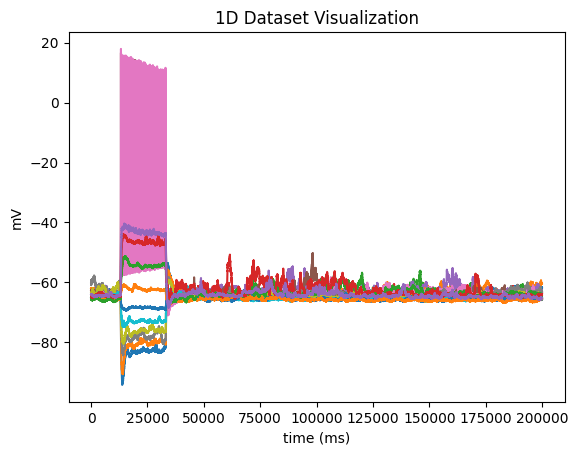

[array([-64.99023583, -64.98413231, -65.02075341, ..., -61.96289201,
        -61.94458146, -62.03003068]),
 array([-61.98730607, -61.91406388, -61.96899553, ..., -60.37597791,
        -60.32714979, -60.32104627]),
 array([-65.29541162, -65.30151513, -65.33813623, ..., -63.05542133,
        -63.02490375, -62.93945453]),
 array([-62.93945453, -62.98828266, -63.04931782, ..., -64.25781394,
        -64.18457175, -64.2456069 ]),
 array([-64.25781394, -64.17236472, -64.22729636, ..., -63.17749165,
        -63.17138813, -63.13476704]),
 array([-63.09814594, -63.16528461, -63.19580219, ..., -65.66162256,
        -65.62500147, -65.56396631]),
 array([-65.67382959, -65.65551905, -65.59448389, ..., -63.71460103,
        -63.71460103, -63.79394674]),
 array([-60.4492201 , -60.46753065, -60.41870252, ..., -63.53759908,
        -63.56201314, -63.55590962]),
 array([-63.51318501, -63.51928853, -63.5070815 , ..., -65.81421046,
        -65.8691421 , -65.832521  ]),
 array([-65.82031397, -65.90576319, -

In [73]:

file_path = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C10.nwb"
data = visualize_hdf5_data(file_path)
data

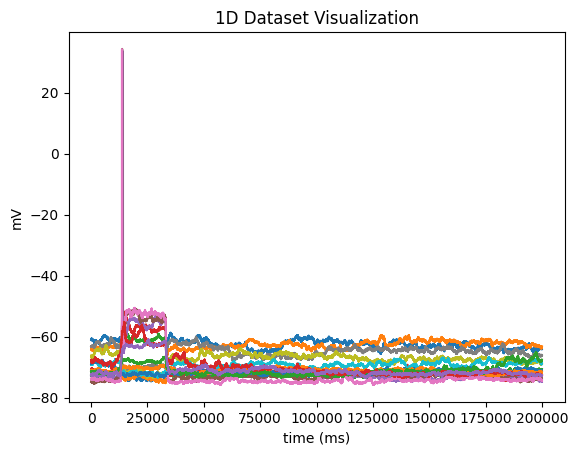

[array([-60.96801894, -60.90698378, -60.91919081, ..., -64.17236472,
        -64.11743307, -64.09912253]),
 array([-64.18457175, -64.14184714, -64.11132956, ..., -63.36670064,
        -63.39721821, -63.31787251]),
 array([-72.77832194, -72.86377116, -72.86987468, ..., -70.69702306,
        -70.73974767, -70.68481603]),
 array([-70.73974767, -70.68481603, -70.72754064, ..., -72.46093912,
        -72.51587076, -72.43652506]),
 array([-72.50366373, -72.48535318, -72.44262857, ..., -74.80468917,
        -74.85962081, -74.89013839]),
 array([-74.84131027, -74.78637862, -74.84741378, ..., -73.84033368,
        -73.85864423, -73.91357587]),
 array([-73.85864423, -73.88305829, -73.88305829, ..., -74.24316572,
        -74.24926924, -74.3103044 ]),
 array([-63.37890767, -63.3911147 , -63.34839009, ..., -66.24756007,
        -66.18652492, -66.24145656]),
 array([-66.31469875, -66.23535304, -66.30859523, ..., -69.0063492 ,
        -69.01855623, -69.0856949 ]),
 array([-69.06738436, -69.03076326, -

In [74]:

file_path = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C14.nwb"
data = visualize_hdf5_data(file_path)
data

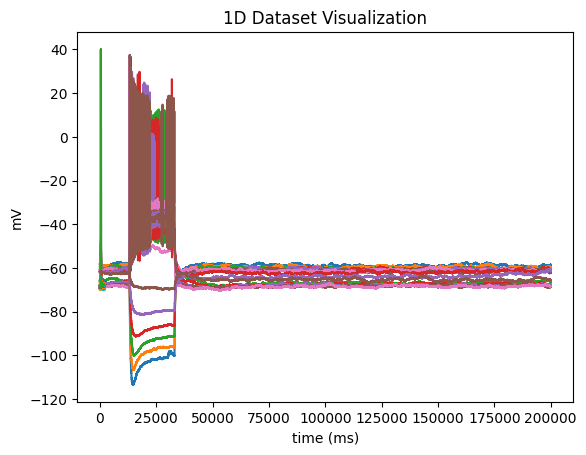

[array([-58.19091927, -58.22754036, -58.22754036, ..., -58.52661264,
        -58.45947396, -58.53881967]),
 array([-58.58154428, -58.52661264, -58.52661264, ..., -59.57031383,
        -59.58252086, -59.62524547]),
 array([-65.50903467, -65.45410303, -65.42358545, ..., -66.26587062,
        -66.26587062, -66.20483546]),
 array([-66.30249172, -66.23535304, -66.25976711, ..., -68.1152359 ,
        -68.12133941, -68.05420074]),
 array([-68.07251129, -68.10913238, -68.05420074, ..., -67.60864409,
        -67.57202299, -67.59033354]),
 array([-67.65747222, -67.62085112, -67.55371245, ..., -68.67065583,
        -68.63403474, -68.60962067]),
 array([-68.70117341, -68.67065583, -68.64013825, ..., -68.36548004,
        -68.3105484 , -68.38989411]),
 array([-69.25489044, -69.26709747, -69.18775177, ..., -69.3159256 ,
        -69.27320099, -69.37085724]),
 array([-69.75537872, -69.67603302, -69.6699295 , ..., -69.9812088 ,
        -69.94458771, -69.92017365]),
 array([-68.88257599, -68.90088654, -

In [75]:

file_path = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C19.nwb"
data = visualize_hdf5_data(file_path)
data